In [157]:
import sys
import os
sys.path.append(os.path.dirname(os.getcwd()))
from shared.collect_data import DataCollector
from shared.clean_data import DataCleaning
import ta
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix
import seaborn as sns
import pandas as pd
import numpy as np

# Data Collection

In [350]:
data_collector = DataCollector(
    symbol = "BTC/USDT", 
    timeframe = "1h", 
    days = 1825,
    limit = 1000
)
df = data_collector.collect_data()

In [351]:
df.head()

,timestamp,open,high,low,close,volume
0,2020-10-30 06:00:00,13181.56,13293.80,13146.48,13201.99,4678.131683
1,2020-10-30 07:00:00,13201.99,13261.22,13115.00,13218.96,3618.574721
2,2020-10-30 08:00:00,13218.96,13338.85,13188.91,13242.48,3603.382745
3,2020-10-30 09:00:00,13242.49,13298.43,13147.66,13277.05,3228.077345
4,2020-10-30 10:00:00,13277.04,13338.96,13210.86,13301.62,2822.142274


In [352]:
df.tail()

,timestamp,open,high,low,close,volume
43775,2025-10-29 01:00:00,112442.87,112975.75,112100.00,112500.03,916.66416
43776,2025-10-29 02:00:00,112500.03,112780.00,112414.47,112666.75,352.69724
43777,2025-10-29 03:00:00,112666.75,112666.75,112339.77,112523.49,301.56130
43778,2025-10-29 04:00:00,112523.49,112878.65,112505.58,112810.55,311.50456
43779,2025-10-29 05:00:00,112810.56,113087.44,112807.34,112972.00,273.47834


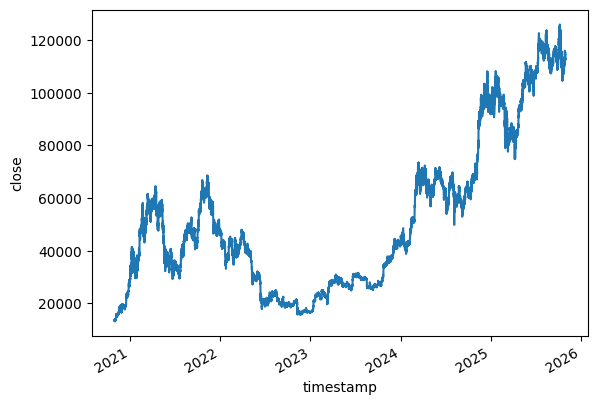

In [353]:
sns.lineplot(x="timestamp", y="close", data=df)
plt.gcf().autofmt_xdate()
plt.show()

In [354]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43780 entries, 0 to 43779
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  43780 non-null  datetime64[ns]
 1   open       43780 non-null  float64       
 2   high       43780 non-null  float64       
 3   low        43780 non-null  float64       
 4   close      43780 non-null  float64       
 5   volume     43780 non-null  float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 2.0 MB


In [355]:
df.describe()

,timestamp,open,high,low,close,volume
count,43780,43780.000000,43780.000000,43780.000000,43780.000000,43780.000000
mean,2023-05-01 01:15:38.318867200,51813.001696,52019.366207,51598.362418,51815.281782,3202.360593
min,2020-10-30 06:00:00,13181.560000,13261.220000,13115.000000,13201.990000,0.000000
25%,2022-01-30 01:45:00,27944.027500,28041.375000,27870.205000,27945.165000,798.229537
50%,2023-05-01 03:30:00,43505.010000,43697.395000,43302.005000,43506.305000,1586.342010
75%,2024-07-30 04:15:00,66162.470000,66385.732500,65877.010000,66164.497500,3502.763617
max,2025-10-29 05:00:00,126011.180000,126199.630000,125252.740000,126011.180000,137207.188600
std,NaN,29151.248152,29224.869445,29076.684085,29152.128587,4725.288162


# Technical Indicators

### Momentum

In [356]:
##Awesome Oscillator (AO)
df["AO"] = ta.momentum.AwesomeOscillatorIndicator(
    high=df["high"],
    low=df["low"],
    window1=5,
    window2=34
).awesome_oscillator()

##KAMA
df["KAMA"] = ta.momentum.KAMAIndicator(close=df['close']).kama()

## PPO
ppo = ta.momentum.PercentagePriceOscillator(
    close=df['close'],
    window_slow=26,
    window_fast=12,
    window_sign=9
)

df["PPO"] = ppo.ppo()

df["PPO_HIST"] = ppo.ppo_hist()

df["PPO_SIGNAL"] = ppo.ppo_signal()

## PVO
pvo = ta.momentum.PercentageVolumeOscillator(
    volume =df['volume'],
    window_slow=26,
    window_fast=12,
    window_sign=9
)

df["PVO"] = pvo.pvo()

df["PVO_HIST"] = pvo.pvo_hist()

df["PVO_SIGNAL"] = pvo.pvo_signal()

## ROC
df["ROC"] = ta.momentum.ROCIndicator(
    close=df['close'],
    window=12
).roc()

## RSI
df["RSI"] = ta.momentum.RSIIndicator(close=df['close'], window=14).rsi()

## STOCHASTIC RSI
df["STOCH_RSI"] = ta.momentum.StochRSIIndicator(
    close=df['close'],
    window=14,
    smooth1=3,
    smooth2=3
).stochrsi()

## STOCHASTIC OSCILLATOR
stoch = ta.momentum.StochasticOscillator(
    high=df['high'],
    low=df['low'],
    close=df['close'],
    window=14,
    smooth_window=3
)

df["STOCH_OSC"] = stoch.stoch()

df["STOCH_OSC_SIGNAL"] = stoch.stoch_signal()

## TSI
df["TSI"] = ta.momentum.TSIIndicator(
    close=df['close'],
    window_slow=25,
    window_fast=13
).tsi()

### Volume

In [357]:
## ADI
adi = ta.volume.AccDistIndexIndicator(
    high=df['high'],
    low=df['low'],
    close=df['close'],
    volume=df['volume']
)

df["ADI"] = adi.acc_dist_index()

## CMF
cmf = ta.volume.ChaikinMoneyFlowIndicator(
    high=df['high'],
    low=df['low'],
    close=df['close'],
    volume=df['volume'],
    window=20
)

df["CMF"] = cmf.chaikin_money_flow()

##EoM EMV
emi = ta.volume.EaseOfMovementIndicator(
    high=df["high"], low=df["low"], volume=df["volume"], window=14
)

df["EoM"] = emi.ease_of_movement()
df["EMV"] = emi.sma_ease_of_movement()

##FI
fi = ta.volume.ForceIndexIndicator(
    close=df["close"], volume=df["volume"], window=13
)

df["FI"] = fi.force_index()

##MFI
mfi = ta.volume.MFIIndicator(
    high=df["high"], low=df["low"], close=df["close"], volume=df["volume"], window=14
)

df["MFI"] = mfi.money_flow_index()

##NVI
nvi = ta.volume.NegativeVolumeIndexIndicator(
    close=df["close"], volume=df["volume"]
)

df["NVI"] = nvi.negative_volume_index()

##OBV
obv = ta.volume.OnBalanceVolumeIndicator(
    close=df["close"], volume=df["volume"]
)

df["OBV"] = obv.on_balance_volume()

##VPT
vpt = ta.volume.VolumePriceTrendIndicator(
    close=df["close"], volume=df["volume"]
)

df["VPT"] = vpt.volume_price_trend()

## VWAP
vwap = ta.volume.VolumeWeightedAveragePrice(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    volume=df["volume"],
    window=14
)

df["VWAP"] = vwap.volume_weighted_average_price()

### Volatility

In [358]:
## ATR
atr = ta.volatility.AverageTrueRange(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=14,
)

df["ATR"] = atr.average_true_range()

## BBANDS
bbands = ta.volatility.BollingerBands(
    close=df["close"],
    window=20,
    window_dev=2
)

df["BBANDS_HIGH"] = bbands.bollinger_hband()
df["BBANDS_HIGH_INDI"] = bbands.bollinger_hband_indicator()
df["BBANDS_LOWER"] = bbands.bollinger_lband()
df["BBANDS_LOWER_INDI"] = bbands.bollinger_lband_indicator()
df["BBANDS_MIDDLE"] = bbands.bollinger_mavg()
df["BBANDS_CHANNEL"] = bbands.bollinger_pband()
df["BBANDS_WIDTH"] = bbands.bollinger_wband()

## DONCHIAN CHANNEL
donchian = ta.volatility.DonchianChannel(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=20
)

df["DONCHIAN_HIGH"] = donchian.donchian_channel_hband()
df["DONCHIAN_LOW"] = donchian.donchian_channel_lband()
df["DONCHIAN_MIDDLE"] = donchian.donchian_channel_mband()
df["DONCHIAN_PERCENTAGE"] = donchian.donchian_channel_pband()
df["DONCHIAN_WIDTH"] = donchian.donchian_channel_wband()

## KELTNER CHANNEL
keltner = ta.volatility.KeltnerChannel(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=20,
    window_atr=10,
)

df["KELTNER_HIGH"] = keltner.keltner_channel_hband()
df["KELTNER_HIGH_INDI"] = keltner.keltner_channel_hband_indicator()
df["KELTNER_LOW"] = keltner.keltner_channel_lband()
df["KELTNER_LOW_INDI"] = keltner.keltner_channel_lband_indicator()
df["KELTNER_MIDDLE"] = keltner.keltner_channel_mband()
df["KELTNER_PERCENTAGE"] = keltner.keltner_channel_pband()
df["KELTNER_WIDTH"] = keltner.keltner_channel_wband()

## Ulcer Index
ui = ta.volatility.UlcerIndex(
    close=df["close"],
    window=14
)

df["ULCER_INDEX"] = ui.ulcer_index()

### Trend

In [359]:
## ADX
adx = ta.trend.ADXIndicator(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=14,
)

df["ADX"] = adx.adx()
df["ADX_POS"] = adx.adx_pos()
df["ADX_NEG"] = adx.adx_neg()

## AROON
aroon = ta.trend.AroonIndicator(
    high=df["high"],
    low=df["low"],
    window=25
)

df["AROON_UP"] = aroon.aroon_up()
df["AROON_DOWN"] = aroon.aroon_down()
df["AROON_INDI"] = aroon.aroon_indicator()

## CCI
cci = ta.trend.CCIIndicator(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=20
)

df["CCI"] = cci.cci()

## DPO
dpo = ta.trend.DPOIndicator(
    close=df["close"],
    window=20
)

df["DPO"] = dpo.dpo()

## EMA
ema = ta.trend.EMAIndicator(
    close=df["close"],
    window=14
)

df["EMA"] = ema.ema_indicator()

## KST
kst = ta.trend.KSTIndicator(
    close=df["close"],
    roc1=10,
    roc2=15,
    roc3=20,
    roc4=30,
    window1=10,
    window2=10,
    window3=10,
    window4=15,
    nsig =9
)

df["KST"] = kst.kst()
df["KST_SIGNAL"] = kst.kst_sig()
df["KST_DIFF"] = kst.kst_diff()

## MACD
macd = ta.trend.MACD(
    close=df["close"],
    window_slow=26,
    window_fast=12,
    window_sign=9
)

df["MACD"] = macd.macd()
df["MACD_SIGNAL"] = macd.macd_signal()
df["MACD_DIFF"] = macd.macd_diff()

## MI
mi = ta.trend.MassIndex(
    high=df["high"],
    low=df["low"],
    window_slow=25,
    window_fast=9
)

df["MASS_INDEX"] = mi.mass_index()

## SMA
sma = ta.trend.SMAIndicator(
    close=df["close"],
    window=14
)

df["SMA"] = sma.sma_indicator()

## VI
vi = ta.trend.VortexIndicator(
    high=df["high"],
    low=df["low"],
    close=df["close"],
    window=14
)

df["VI_POS"] = vi.vortex_indicator_pos()
df["VI_NEG"] = vi.vortex_indicator_neg()
df["VI_DIFF"] = vi.vortex_indicator_diff()

## WMA
wma = ta.trend.WMAIndicator(
    close=df["close"],
    window=14
)

df["WMA"] = wma.wma()

# Data Cleaning

In [360]:
dataset = df.copy()
data_cleaning = DataCleaning()
dataset = data_cleaning.dropna(dataset)
dataset = data_cleaning.drop_duplicates(dataset)

In [361]:
dataset.head()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,PPO_SIGNAL,PVO,PVO_HIST,PVO_SIGNAL,ROC,RSI,STOCH_RSI,STOCH_OSC,STOCH_OSC_SIGNAL,TSI,ADI,CMF,EoM,EMV,FI,MFI,NVI,OBV,VPT,VWAP,ATR,BBANDS_HIGH,BBANDS_HIGH_INDI,BBANDS_LOWER,BBANDS_LOWER_INDI,BBANDS_MIDDLE,BBANDS_CHANNEL,BBANDS_WIDTH,DONCHIAN_HIGH,DONCHIAN_LOW,DONCHIAN_MIDDLE,DONCHIAN_PERCENTAGE,DONCHIAN_WIDTH,KELTNER_HIGH,KELTNER_HIGH_INDI,KELTNER_LOW,KELTNER_LOW_INDI,KELTNER_MIDDLE,KELTNER_PERCENTAGE,KELTNER_WIDTH,ULCER_INDEX,ADX,ADX_POS,ADX_NEG,AROON_UP,AROON_DOWN,AROON_INDI,CCI,DPO,EMA,KST,KST_SIGNAL,KST_DIFF,MACD,MACD_SIGNAL,MACD_DIFF,MASS_INDEX,SMA,VI_POS,VI_NEG,VI_DIFF,WMA
40,2020-10-31 22:00:00,13838.83,13890.00,13816.38,13866.99,1353.164551,140.509647,13725.676084,0.631176,-0.074069,0.705244,-19.422475,-9.826500,-9.595975,0.327528,61.923741,0.405740,55.835861,52.876378,23.567045,20530.099587,0.133313,1.379731e+08,4.410952e+07,28777.886696,43.983816,1025.685116,20362.571816,203.751699,13835.334761,123.031332,14034.087408,0.0,13476.566592,0.0,13755.3270,0.700285,4.053127,14100.0,13411.50,13755.750,0.661569,5.005334,13884.465000,0.0,13609.490000,0.0,13746.977500,0.936449,2.000258,0.815711,22.109833,20.798760,15.917440,52.0,24.0,28.0,64.748722,184.6730,13790.947922,-57.251227,-136.888061,79.636834,86.567496,96.386887,-9.819391,25.024258,13835.532143,1.124160,0.974269,0.149891,13823.150667
41,2020-10-31 23:00:00,13866.89,13869.64,13762.61,13791.00,1667.822760,140.188382,13727.305923,0.577877,-0.101894,0.679771,-19.983856,-8.310305,-11.673551,-1.068867,55.552902,0.109675,41.432904,49.255118,21.877463,19747.065917,0.135345,-2.378590e+08,-7.686721e+06,6561.352663,33.220671,1025.685116,18694.749056,194.612163,13830.715076,121.888380,14021.593451,0.0,13519.006549,0.0,13770.3000,0.541187,3.649789,14100.0,13452.50,13776.250,0.522780,4.702149,13894.265000,0.0,13629.632000,0.0,13761.948500,0.609780,1.922933,0.864286,20.799951,19.491462,18.074661,48.0,20.0,28.0,30.581852,108.2000,13790.954865,-37.916713,-116.781022,78.864309,79.289882,92.967486,-13.677604,24.892864,13828.229286,1.022398,1.047648,-0.025250,13817.213048
42,2020-11-01 00:00:00,13791.00,13895.00,13660.00,13725.95,3504.288678,133.417706,13727.264432,0.491903,-0.150294,0.642197,-13.759870,-1.669055,-12.090815,-1.099182,50.740420,0.000000,22.741379,40.003381,18.976013,18209.652458,0.088843,-2.590219e+08,-2.538539e+07,-26940.837504,44.279795,1025.685116,15190.460378,178.082979,13822.160835,129.967781,14004.807884,0.0,13556.771116,0.0,13780.7895,0.377600,3.251169,14100.0,13463.87,13781.935,0.411991,4.616064,13915.934167,0.0,13634.417167,0.0,13775.175667,0.325141,2.043655,0.946823,20.136679,16.969427,21.385689,44.0,16.0,28.0,-11.985582,80.1705,13782.287550,-19.065867,-96.975479,77.909612,67.495285,87.873046,-20.377761,24.988257,13821.388571,1.057465,1.134496,-0.077031,13803.575810
43,2020-11-01 01:00:00,13725.96,13772.02,13707.68,13759.90,971.786119,114.402971,13728.383266,0.438597,-0.162880,0.601477,-17.533849,-4.354427,-13.179422,-0.729098,53.027509,0.138647,35.525052,33.233112,17.190430,18815.319592,0.113116,-2.492731e+08,-5.618843e+07,-18378.983755,36.027644,1028.222063,16162.246497,180.486611,13810.395378,125.280082,13969.864188,0.0,13620.378812,0.0,13795.1215,0.399219,2.533398,14100.0,13463.87,13781.935,0.465361,4.611268,13929.294167,0.0,13646.632167,0.0,13787.963167,0.400718,2.050063,0.973980,19.520783,16.345819,20.599789,40.0,12.0,28.0,-41.133344,16.3485,13779.302543,0.081364,-77.347640,77.429004,60.193589,82.337155,-22.143565,24.948610,13808.524286,0.932562,1.123292,-0.190730,13795.377333
44,2020-11-01 02:00:00,13759.91,13774.96,13686.14,13715.88,903.824302,89.259618,13727.903450,0.366345,-0.188106,0.554451,-20.972533,-6.234489,-14.738044,-0.692106,49.798959,0.000000,20.696296,26.320909,14.728767,18516.758401,0.084721,-9.139232e+07,-6.680786e+07,-21437.178329,39.211527,1024.932625,15258.422195,177.595141,13797.370461,122.675791,13958.363652,0.0,13642.262348,0.0,13800.3130,0.232893,2.290537,14100.0,13550.73,13825.

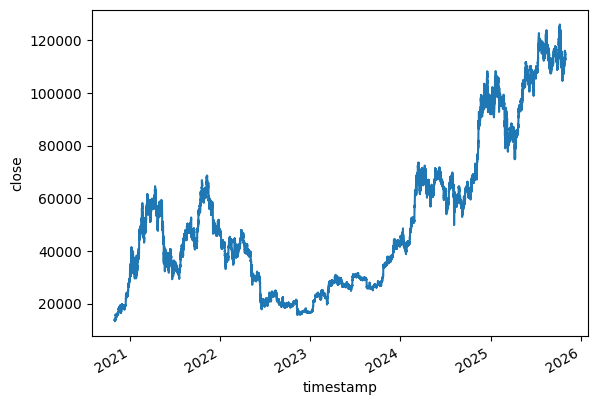

In [362]:
sns.lineplot(x="timestamp", y="close", data=dataset)
plt.gcf().autofmt_xdate()
plt.show()

In [363]:
dataset.head()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,PPO_SIGNAL,PVO,PVO_HIST,PVO_SIGNAL,ROC,RSI,STOCH_RSI,STOCH_OSC,STOCH_OSC_SIGNAL,TSI,ADI,CMF,EoM,EMV,FI,MFI,NVI,OBV,VPT,VWAP,ATR,BBANDS_HIGH,BBANDS_HIGH_INDI,BBANDS_LOWER,BBANDS_LOWER_INDI,BBANDS_MIDDLE,BBANDS_CHANNEL,BBANDS_WIDTH,DONCHIAN_HIGH,DONCHIAN_LOW,DONCHIAN_MIDDLE,DONCHIAN_PERCENTAGE,DONCHIAN_WIDTH,KELTNER_HIGH,KELTNER_HIGH_INDI,KELTNER_LOW,KELTNER_LOW_INDI,KELTNER_MIDDLE,KELTNER_PERCENTAGE,KELTNER_WIDTH,ULCER_INDEX,ADX,ADX_POS,ADX_NEG,AROON_UP,AROON_DOWN,AROON_INDI,CCI,DPO,EMA,KST,KST_SIGNAL,KST_DIFF,MACD,MACD_SIGNAL,MACD_DIFF,MASS_INDEX,SMA,VI_POS,VI_NEG,VI_DIFF,WMA
40,2020-10-31 22:00:00,13838.83,13890.00,13816.38,13866.99,1353.164551,140.509647,13725.676084,0.631176,-0.074069,0.705244,-19.422475,-9.826500,-9.595975,0.327528,61.923741,0.405740,55.835861,52.876378,23.567045,20530.099587,0.133313,1.379731e+08,4.410952e+07,28777.886696,43.983816,1025.685116,20362.571816,203.751699,13835.334761,123.031332,14034.087408,0.0,13476.566592,0.0,13755.3270,0.700285,4.053127,14100.0,13411.50,13755.750,0.661569,5.005334,13884.465000,0.0,13609.490000,0.0,13746.977500,0.936449,2.000258,0.815711,22.109833,20.798760,15.917440,52.0,24.0,28.0,64.748722,184.6730,13790.947922,-57.251227,-136.888061,79.636834,86.567496,96.386887,-9.819391,25.024258,13835.532143,1.124160,0.974269,0.149891,13823.150667
41,2020-10-31 23:00:00,13866.89,13869.64,13762.61,13791.00,1667.822760,140.188382,13727.305923,0.577877,-0.101894,0.679771,-19.983856,-8.310305,-11.673551,-1.068867,55.552902,0.109675,41.432904,49.255118,21.877463,19747.065917,0.135345,-2.378590e+08,-7.686721e+06,6561.352663,33.220671,1025.685116,18694.749056,194.612163,13830.715076,121.888380,14021.593451,0.0,13519.006549,0.0,13770.3000,0.541187,3.649789,14100.0,13452.50,13776.250,0.522780,4.702149,13894.265000,0.0,13629.632000,0.0,13761.948500,0.609780,1.922933,0.864286,20.799951,19.491462,18.074661,48.0,20.0,28.0,30.581852,108.2000,13790.954865,-37.916713,-116.781022,78.864309,79.289882,92.967486,-13.677604,24.892864,13828.229286,1.022398,1.047648,-0.025250,13817.213048
42,2020-11-01 00:00:00,13791.00,13895.00,13660.00,13725.95,3504.288678,133.417706,13727.264432,0.491903,-0.150294,0.642197,-13.759870,-1.669055,-12.090815,-1.099182,50.740420,0.000000,22.741379,40.003381,18.976013,18209.652458,0.088843,-2.590219e+08,-2.538539e+07,-26940.837504,44.279795,1025.685116,15190.460378,178.082979,13822.160835,129.967781,14004.807884,0.0,13556.771116,0.0,13780.7895,0.377600,3.251169,14100.0,13463.87,13781.935,0.411991,4.616064,13915.934167,0.0,13634.417167,0.0,13775.175667,0.325141,2.043655,0.946823,20.136679,16.969427,21.385689,44.0,16.0,28.0,-11.985582,80.1705,13782.287550,-19.065867,-96.975479,77.909612,67.495285,87.873046,-20.377761,24.988257,13821.388571,1.057465,1.134496,-0.077031,13803.575810
43,2020-11-01 01:00:00,13725.96,13772.02,13707.68,13759.90,971.786119,114.402971,13728.383266,0.438597,-0.162880,0.601477,-17.533849,-4.354427,-13.179422,-0.729098,53.027509,0.138647,35.525052,33.233112,17.190430,18815.319592,0.113116,-2.492731e+08,-5.618843e+07,-18378.983755,36.027644,1028.222063,16162.246497,180.486611,13810.395378,125.280082,13969.864188,0.0,13620.378812,0.0,13795.1215,0.399219,2.533398,14100.0,13463.87,13781.935,0.465361,4.611268,13929.294167,0.0,13646.632167,0.0,13787.963167,0.400718,2.050063,0.973980,19.520783,16.345819,20.599789,40.0,12.0,28.0,-41.133344,16.3485,13779.302543,0.081364,-77.347640,77.429004,60.193589,82.337155,-22.143565,24.948610,13808.524286,0.932562,1.123292,-0.190730,13795.377333
44,2020-11-01 02:00:00,13759.91,13774.96,13686.14,13715.88,903.824302,89.259618,13727.903450,0.366345,-0.188106,0.554451,-20.972533,-6.234489,-14.738044,-0.692106,49.798959,0.000000,20.696296,26.320909,14.728767,18516.758401,0.084721,-9.139232e+07,-6.680786e+07,-21437.178329,39.211527,1024.932625,15258.422195,177.595141,13797.370461,122.675791,13958.363652,0.0,13642.262348,0.0,13800.3130,0.232893,2.290537,14100.0,13550.73,13825.

# Feature Engineering

### Timestamp Features

In [364]:
dataset["hour"] = dataset['timestamp'].dt.hour
dataset['dayofweek'] = dataset['timestamp'].dt.dayofweek
dataset['quarter'] = dataset['timestamp'].dt.quarter
dataset['month'] = dataset['timestamp'].dt.month
dataset['year'] = dataset['timestamp'].dt.year
dataset['dayofyear'] = dataset['timestamp'].dt.dayofyear
dataset['dayofmonth'] = dataset['timestamp'].dt.day

In [365]:
dataset.tail()

,timestamp,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,PPO_SIGNAL,PVO,PVO_HIST,PVO_SIGNAL,ROC,RSI,STOCH_RSI,STOCH_OSC,STOCH_OSC_SIGNAL,TSI,ADI,CMF,EoM,EMV,FI,MFI,NVI,OBV,VPT,VWAP,ATR,BBANDS_HIGH,BBANDS_HIGH_INDI,BBANDS_LOWER,BBANDS_LOWER_INDI,BBANDS_MIDDLE,BBANDS_CHANNEL,BBANDS_WIDTH,DONCHIAN_HIGH,DONCHIAN_LOW,DONCHIAN_MIDDLE,DONCHIAN_PERCENTAGE,DONCHIAN_WIDTH,KELTNER_HIGH,KELTNER_HIGH_INDI,KELTNER_LOW,KELTNER_LOW_INDI,KELTNER_MIDDLE,KELTNER_PERCENTAGE,KELTNER_WIDTH,ULCER_INDEX,ADX,ADX_POS,ADX_NEG,AROON_UP,AROON_DOWN,AROON_INDI,CCI,DPO,EMA,KST,KST_SIGNAL,KST_DIFF,MACD,MACD_SIGNAL,MACD_DIFF,MASS_INDEX,SMA,VI_POS,VI_NEG,VI_DIFF,WMA,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth
43775,2025-10-29 01:00:00,112442.87,112975.75,112100.00,112500.03,916.66416,-1459.119353,113736.425384,-0.408024,-0.215604,-0.192420,1.326263,-0.947599,2.273862,-2.616685,35.028730,0.024417,10.035876,11.253507,-17.949640,4.241104e+06,-0.009445,-1.268583e+10,-1.649327e+10,-197710.255200,22.877610,88935.357833,956357.873783,-3423.824038,114047.806265,718.008072,116022.316340,0.0,112188.426660,0.0,114105.3715,0.081276,3.359955,116086.0,112100.0,114093.0,0.100359,3.493262,114833.893500,0.0,113372.508500,1.0,114103.201000,-0.597022,1.280757,1.623778,27.760657,12.217716,31.896567,56.0,100.0,-44.0,-134.986388,962.7985,113567.955318,-7.532551,-2.968035,-4.564516,-464.839382,-219.369712,-245.469671,26.363025,113992.447857,0.822932,1.136842,-0.313910,113472.508952,1,2,4,10,2025,302,29
43776,2025-10-29 02:00:00,112500.03,112780.00,112414.47,112666.75,352.69724,-1405.170794,113498.321946,-0.433671,-0.193001,-0.240670,-2.997195,-4.216845,1.219651,-2.086954,37.206551,0.097737,14.218515,10.079463,-19.185862,4.241239e+06,-0.030067,6.151979e+09,-1.504145e+10,-161065.692478,26.123100,89067.156045,956710.571023,-3423.301357,113991.108498,692.831066,116049.760692,0.0,112016.105308,0.0,114032.9330,0.161304,3.537272,116086.0,112100.0,114093.0,0.142185,3.495481,114755.708333,0.0,113315.839333,1.0,114035.773833,-0.450797,1.262647,1.752743,28.964095,11.757293,30.694548,52.0,96.0,-44.0,-108.837056,608.4470,113447.794609,-9.081121,-3.841641,-5.239480,-493.652643,-274.226298,-219.426345,26.261405,113865.105000,0.860937,1.140169,-0.279232,113295.749238,2,2,4,10,2025,302,29
43777,2025-10-29 03:00:00,112666.75,112666.75,112339.77,112523.49,301.56130,-1428.908706,113277.250174,-0.458990,-0.174656,-0.284334,-7.289635,-6.807429,-0.482206,-1.847404,36.087176,0.073116,10.624436,11.626275,-20.528930,4.241276e+06,-0.015101,-1.018962e+10,-2.059816e+10,-144227.975244,17.954559,88953.903814,956409.009723,-3423.684803,113831.971253,666.698847,116068.822594,0.0,111830.555406,0.0,113949.6890,0.163495,3.719420,116086.0,112100.0,114093.0,0.106244,3.498035,114673.135667,0.0,113227.916667,1.0,113950.526167,-0.487419,1.268286,1.870429,30.157390,11.345413,30.419578,48.0,92.0,-44.0,-100.946622,1391.9010,113324.553995,-10.734712,-4.981249,-5.753462,-522.029612,-323.786961,-198.242651,25.994806,113650.861429,0.818871,1.245208,-0.426337,113116.867238,3,2,4,10,2025,302,29
43778,2025-10-29 04:00:00,112523.49,112878.65,112505.58,112810.55,311.50456,-1406.574676,113205.489940,-0.453446,-0.135290,-0.318156,-10.764798,-8.226073,-2.538725,-2.194386,39.983537,0.232833,20.351377,15.064776,-20.542651,4.241474e+06,-0.016682,2.261801e+10,-2.021437e+10,-110849.621781,24.449207,88953.903814,956720.514283,-3422.890120,113532.499439,645.725358,116031.841153,0.0,111705.868847,0.0,113868.8550,0.255360,3.799083,116086.0,112100.0,114093.0,0.178261,3.500518,114593.012333,0.0,113147.175333,1.0,113870.093833,-0.232824,1.269725,1.957393,30.690035,13.221195,29.164220,44.0,88.0,-44.0,-75.835792,1421.1450,113256.020129,-12.604467,-6.313818,-6.290649,-515.413851,-362.112339,-153.301512,25.782892,113489.602857,0.830877,1.315727,-0.484850,113004.825714,4,2,4,10,2025,302,29
43779,2025-10-29 05:00:00,112810.56,113087.44,112807.34,112972.00,273.47834,-1288.901912,113194.810471,-0.432583,-0.091542,-0.341042,-14.211536,-9.338249,-

In [366]:
dataset = data_cleaning.dropna(dataset)
dataset = data_cleaning.drop_duplicates(dataset)

# Feature Selection

In [367]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, TimeSeriesSplit
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

In [368]:
dataset = dataset.sort_values('timestamp')

In [369]:
X_close = dataset.drop(['timestamp', 'close'], axis=1)
y_close = dataset['close']

### Feature Importance

In [370]:
xgb_close = XGBRegressor(
    device='cuda',
    max_bin=256,
    eval_metric='rmse',
)

In [371]:
tscv = TimeSeriesSplit(n_splits=100)

##### Train the model

In [372]:
## Train the model
def model_training(X, y, model, tscv):
    fold_metrics = []
    n = len(X)
    oof_pred = np.full(shape=n, fill_value=np.nan, dtype=float)
    feature_names = X.columns.tolist()
    fold_id = 0
    gain_accum = pd.Series(0.0, index=feature_names)

    for train_idx, val_idx in tscv.split(X):
        fold_id += 1
        X_train, X_test = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(
            X_train, y_train,
            eval_set=[(X_test, y_test)],
            verbose=False,
        )

        # OOF predictions for this fold’s validation window
        y_val_pred = model.predict(X_test)
        oof_pred[val_idx] = y_val_pred

        # Fold metrics
        rmse = root_mean_squared_error(y_test, y_val_pred)
        mae  = mean_absolute_error(y_test, y_val_pred)
        fold_metrics.append({"fold": fold_id, "rmse": rmse, "mae": mae})

        # Gain importances for this fold (reindexed to all features, missing -> 0)
        gain_dict = model.get_booster().get_score(importance_type="gain")
        gain_fold = pd.Series(gain_dict, dtype=float)

        # xgboost keys are the raw feature names; ensure alignment
        gain_fold.index = [k for k in gain_fold.index]  # no-op but explicit
        gain_fold = gain_fold.reindex(feature_names).fillna(0.0)
        gain_accum += gain_fold

    return fold_metrics, oof_pred, gain_accum


### Get most value variables

In [373]:
features_by_target = {}
fold_metrics, oof_pred, gain_accum = model_training(X_close, y_close, xgb_close, tscv)
importance_df = (
    gain_accum.div(100)             # average gain across folds
    .sort_values(ascending=False)
    .rename("avg_gain")
    .reset_index()
    .rename(columns={"index": "feature"})
)
importance_df["gain_pct"] = (importance_df["avg_gain"] / importance_df["avg_gain"].sum()) * 100
features_by_target["close"] = importance_df[importance_df["gain_pct"] > 0.5]["feature"].tolist()

In [374]:
features_by_target

{'close': ['high',
  'low',
  'DONCHIAN_HIGH',
  'KELTNER_LOW',
  'EMA',
  'DONCHIAN_LOW',
  'BBANDS_HIGH',
  'BBANDS_MIDDLE',
  'VWAP',
  'KAMA',
  'SMA',
  'DONCHIAN_MIDDLE',
  'ADI',
  'WMA']}

In [375]:
all_features = features_by_target["close"] + ["close"]

### Save Selected Features

In [376]:
import os
import json
from datetime import datetime
model_folder = "saved_models"
os.makedirs(model_folder, exist_ok=True)

In [377]:
with open('feature_selection/features_by_target_1h_lstm.json', 'w') as f:
    json.dump(features_by_target, f, indent=4)

# Scale Data

In [378]:
from sklearn.preprocessing import MinMaxScaler

In [379]:
dataset.set_index('timestamp', inplace=True)

In [380]:
#dataset.drop(['timestamp'], axis=1, inplace=True)

In [381]:
dataset.head()

,open,high,low,close,volume,AO,KAMA,PPO,PPO_HIST,PPO_SIGNAL,PVO,PVO_HIST,PVO_SIGNAL,ROC,RSI,STOCH_RSI,STOCH_OSC,STOCH_OSC_SIGNAL,TSI,ADI,CMF,EoM,EMV,FI,MFI,NVI,OBV,VPT,VWAP,ATR,BBANDS_HIGH,BBANDS_HIGH_INDI,BBANDS_LOWER,BBANDS_LOWER_INDI,BBANDS_MIDDLE,BBANDS_CHANNEL,BBANDS_WIDTH,DONCHIAN_HIGH,DONCHIAN_LOW,DONCHIAN_MIDDLE,DONCHIAN_PERCENTAGE,DONCHIAN_WIDTH,KELTNER_HIGH,KELTNER_HIGH_INDI,KELTNER_LOW,KELTNER_LOW_INDI,KELTNER_MIDDLE,KELTNER_PERCENTAGE,KELTNER_WIDTH,ULCER_INDEX,ADX,ADX_POS,ADX_NEG,AROON_UP,AROON_DOWN,AROON_INDI,CCI,DPO,EMA,KST,KST_SIGNAL,KST_DIFF,MACD,MACD_SIGNAL,MACD_DIFF,MASS_INDEX,SMA,VI_POS,VI_NEG,VI_DIFF,WMA,hour,dayofweek,quarter,month,year,dayofyear,dayofmonth
timestamp,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2020-10-31 22:00:00,13838.83,13890.00,13816.38,13866.99,1353.164551,140.509647,13725.676084,0.631176,-0.074069,0.705244,-19.422475,-9.826500,-9.595975,0.327528,61.923741,0.405740,55.835861,52.876378,23.567045,20530.099587,0.133313,1.379731e+08,4.410952e+07,28777.886696,43.983816,1025.685116,20362.571816,203.751699,13835.334761,123.031332,14034.087408,0.0,13476.566592,0.0,13755.3270,0.700285,4.053127,14100.0,13411.50,13755.750,0.661569,5.005334,13884.465000,0.0,13609.490000,0.0,13746.977500,0.936449,2.000258,0.815711,22.109833,20.798760,15.917440,52.0,24.0,28.0,64.748722,184.6730,13790.947922,-57.251227,-136.888061,79.636834,86.567496,96.386887,-9.819391,25.024258,13835.532143,1.124160,0.974269,0.149891,13823.150667,22,5,4,10,2020,305,31
2020-10-31 23:00:00,13866.89,13869.64,13762.61,13791.00,1667.822760,140.188382,13727.305923,0.577877,-0.101894,0.679771,-19.983856,-8.310305,-11.673551,-1.068867,55.552902,0.109675,41.432904,49.255118,21.877463,19747.065917,0.135345,-2.378590e+08,-7.686721e+06,6561.352663,33.220671,1025.685116,18694.749056,194.612163,13830.715076,121.888380,14021.593451,0.0,13519.006549,0.0,13770.3000,0.541187,3.649789,14100.0,13452.50,13776.250,0.522780,4.702149,13894.265000,0.0,13629.632000,0.0,13761.948500,0.609780,1.922933,0.864286,20.799951,19.491462,18.074661,48.0,20.0,28.0,30.581852,108.2000,13790.954865,-37.916713,-116.781022,78.864309,79.289882,92.967486,-13.677604,24.892864,13828.229286,1.022398,1.047648,-0.025250,13817.213048,23,5,4,10,2020,305,31
2020-11-01 00:00:00,13791.00,13895.00,13660.00,13725.95,3504.288678,133.417706,13727.264432,0.491903,-0.150294,0.642197,-13.759870,-1.669055,-12.090815,-1.099182,50.740420,0.000000,22.741379,40.003381,18.976013,18209.652458,0.088843,-2.590219e+08,-2.538539e+07,-26940.837504,44.279795,1025.685116,15190.460378,178.082979,13822.160835,129.967781,14004.807884,0.0,13556.771116,0.0,13780.7895,0.377600,3.251169,14100.0,13463.87,13781.935,0.411991,4.616064,13915.934167,0.0,13634.417167,0.0,13775.175667,0.325141,2.043655,0.946823,20.136679,16.969427,21.385689,44.0,16.0,28.0,-11.985582,80.1705,13782.287550,-19.065867,-96.975479,77.909612,67.495285,87.873046,-20.377761,24.988257,13821.388571,1.057465,1.134496,-0.077031,13803.575810,0,6,4,11,2020,306,1
2020-11-01 01:00:00,13725.96,13772.02,13707.68,13759.90,971.786119,114.402971,13728.383266,0.438597,-0.162880,0.601477,-17.533849,-4.354427,-13.179422,-0.729098,53.027509,0.138647,35.525052,33.233112,17.190430,18815.319592,0.113116,-2.492731e+08,-5.618843e+07,-18378.983755,36.027644,1028.222063,16162.246497,180.486611,13810.395378,125.280082,13969.864188,0.0,13620.378812,0.0,13795.1215,0.399219,2.533398,14100.0,13463.87,13781.935,0.465361,4.611268,13929.294167,0.0,13646.632167,0.0,13787.963167,0.400718,2.050063,0.973980,19.520783,16.345819,20.599789,40.0,12.0,28.0,-41.133344,16.3485,13779.302543,0.081364,-77.347640,77.429004,60.193589,82.337155,-22.143565,24.948610,13808.524286,0.932562,1.123292,-0.190730,13795.377333,1,6,4,11,2020,306,1
2020-11-01 02:00:00,13759.91,13774.96,13686.14,13715.88,903.824302,89.259618,13727.903450,0.366345,-0.188106,0.554451,-20.972533,-6.234489,-14.738044,-0.692106,49.798959,0.000000,20.696296,26.320909,14.728767,18516.758401,0.084

In [382]:
scaler = MinMaxScaler(feature_range= (0, 1))

In [383]:
scaled_data = scaler.fit_transform(dataset[all_features])

In [384]:
scaled_data

array([[4.15638175e-03, 5.54473325e-03, 3.55556725e-03, ...,
        1.46850806e-03, 3.16981554e-03, 5.05200702e-03],
       [3.97585069e-03, 5.06489113e-03, 3.55556725e-03, ...,
        1.28467522e-03, 3.11664754e-03, 4.37782053e-03],
       [4.20071648e-03, 4.14920208e-03, 3.55556725e-03, ...,
        9.23736601e-04, 2.99453384e-03, 3.80069418e-03],
       ...,
       [8.80004660e-01, 8.84764981e-01, 9.10100771e-01, ...,
        9.92373158e-01, 8.92288503e-01, 8.80336644e-01],
       [8.81883567e-01, 8.86244666e-01, 9.10100771e-01, ...,
        9.92419591e-01, 8.91285235e-01, 8.82883453e-01],
       [8.83734897e-01, 8.88937564e-01, 9.10100771e-01, ...,
        9.92430873e-01, 8.90667257e-01, 8.84315844e-01]],
      shape=(43712, 15))

# Splitting the data

In [385]:
train_size = int(len(dataset) * 0.7)
val_size = int(len(dataset) * 0.15)

In [386]:
train_data = scaled_data[:train_size]
val_data = scaled_data[train_size:train_size+val_size]
test_data = scaled_data[train_size+val_size - 60:]

In [387]:
train_data.shape, val_data.shape, test_data.shape

((30598, 15), (6556, 15), (6618, 15))

# Creating training set

In [388]:
x_train = []
y_train = []
for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i])
    y_train.append(train_data[i, 3])  # Assuming 'close' is the 4th column in all_features

In [389]:
x_train, y_train = np.array(x_train), np.array(y_train)

In [390]:
x_train.shape , y_train.shape

((30538, 60, 15), (30538,))

In [391]:
x_val = []
y_val = []
for i in range(60, len(val_data)):
    x_val.append(val_data[i-60:i])
    y_val.append(val_data[i, 3])  # Assuming 'close' is the 4th column in all_features

In [392]:
x_val, y_val = np.array(x_train), np.array(y_train)

# LSTM Models

In [393]:

import keras
from keras.models import Sequential
from keras.layers import Input, Dense, LSTM, Dropout, Bidirectional
from keras.optimizers import Adam

In [394]:
model = Sequential([
    LSTM(50, return_sequences= True, input_shape= (x_train.shape[1], x_train.shape[2])),
    LSTM(64, return_sequences= False),
    Dense(32),
    Dense(16),
    Dense(1)
])
model.compile(optimizer= Adam(learning_rate=0.001), loss= 'mse' , metrics=['mean_absolute_error'])

c:\Users\DG\Desktop\trading-bot-project\data_analysis_trading_bot\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [395]:
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_20 (LSTM)                  │ (None, 60, 50)         │        13,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_21 (LSTM)                  │ (None, 64)             │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,265 (176.82 KB)

 Trainable params: 45,265 (176.82 KB)

 Non-trainable params: 0 (0.00 B)

### Model training

In [396]:
from keras.callbacks import EarlyStopping

In [397]:
# Fitting the LSTM to the Training set
callbacks = [EarlyStopping(monitor= 'loss', patience= 10 , restore_best_weights= True)]
history = model.fit(x_train, y_train, epochs= 100, batch_size= 32 , callbacks= callbacks )

Epoch 1/100
955/955 ━━━━━━━━━━━━━━━━━━━━ 23s 21ms/step - loss: 2.7033e-04 - mean_absolute_error: 0.0043
Epoch 2/100
955/955 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - loss: 3.9845e-06 - mean_absolute_error: 0.0014
Epoch 3/100
955/955 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - loss: 3.9920e-06 - mean_absolute_error: 0.0015
Epoch 4/100
955/955 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - loss: 6.2469e-06 - mean_absolute_error: 0.0018
Epoch 5/100
955/955 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - loss: 7.1001e-06 - mean_absolute_error: 0.0019
Epoch 6/100
955/955 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - loss: 9.7092e-06 - mean_absolute_error: 0.0017
Epoch 7/100
955/955 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - loss: 5.1540e-06 - mean_absolute_error: 0.0016
Epoch 8/100
955/955 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - loss: 4.9741e-06 - mean_absolute_error: 0.0015
Epoch 9/100
955/955 ━━━━━━━━━━━━━━━━━━━━ 21s 22ms/step - loss: 4.0245e-06 - mean_absolute_error: 0.0014
Epoch 10/100
955/955 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - loss: 

# Model Evaluation

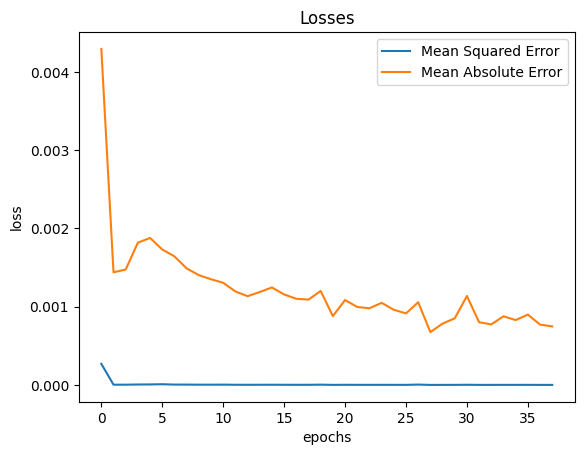

In [398]:
plt.plot(history.history["loss"])
plt.plot(history.history["mean_absolute_error"])
plt.legend(['Mean Squared Error','Mean Absolute Error'])
plt.title("Losses")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.show()

# Prediction

In [399]:
x_test = []
y_test = []

for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i])
    y_test.append(test_data[i, 3])



In [400]:
x_test = np.array(x_test)

In [401]:
y_test = np.array(y_test)

In [402]:
x_test.shape , y_test.shape


((6558, 60, 15), (6558,))

In [403]:
#inverse y_test scaling
predictions = model.predict(x_test)

205/205 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step


In [404]:
predictions.shape

(6558, 1)

In [405]:
pred_temp = np.zeros((predictions.shape[0], x_test.shape[2]))
pred_temp[:,0] = predictions[:,0]  # 0 es la columna Close

predictions_real = scaler.inverse_transform(pred_temp)
predictions_real = predictions_real[:,0]  # nos quedamos solo con Close

In [406]:
y_test.shape, x_test.shape

((6558,), (6558, 60, 15))

In [407]:
y_temp = np.zeros((y_test.shape[0], x_test.shape[2]))
y_temp[:,0] = y_test
y_test_real = scaler.inverse_transform(y_temp)[:,0]

In [408]:
RMSE = np.sqrt(np.mean((y_test_real - predictions_real)**2))
print("Test RMSE:", round(RMSE, 2))

Test RMSE: 2990.84


In [409]:
train = dataset.iloc[:train_size]
val = dataset.iloc[train_size:train_size+val_size]
test = dataset.iloc[train_size+val_size:]

test = test.copy()  # para evitar el famoso Warning de pandas
test['Predictions'] = predictions_real

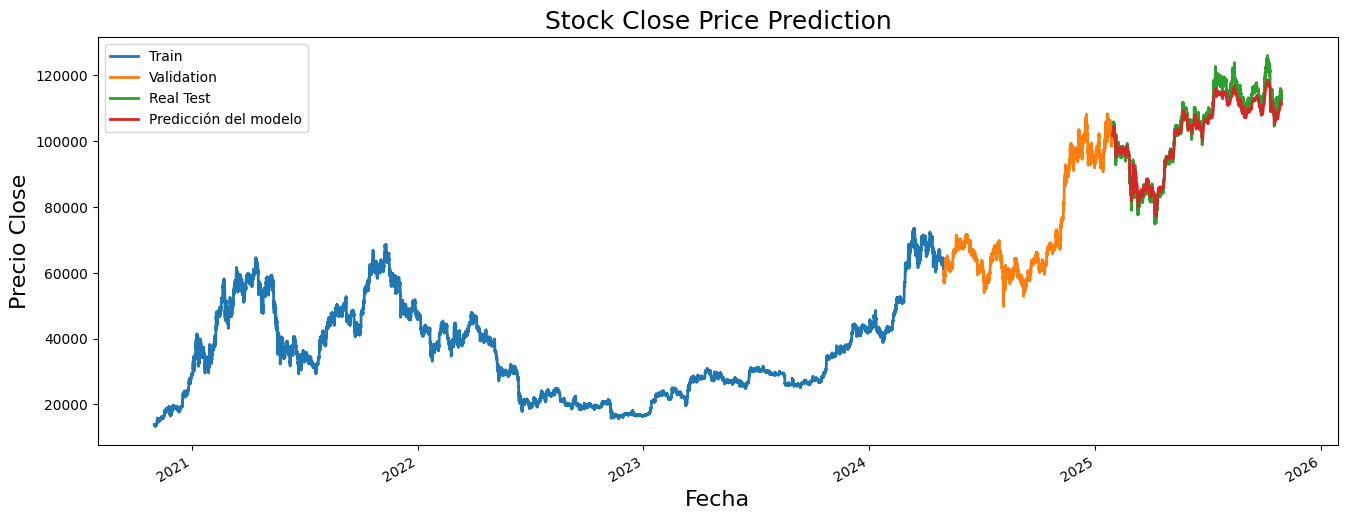

In [410]:
plt.figure(figsize=(16,6))
plt.title('Stock Close Price Prediction', fontsize=18)
plt.xlabel('Fecha', fontsize=16)
plt.ylabel('Precio Close', fontsize=16)

plt.plot(train.index, train['close'], linewidth=2)
plt.plot(val.index, val['close'], linewidth=2)
plt.plot(test.index, test['close'], linewidth=2)
plt.plot(test.index, test['Predictions'], linewidth=2)

plt.legend(['Train', 'Validation', 'Real Test', 'Predicción del modelo'])
plt.gcf().autofmt_xdate()
plt.show()

# Predict next 24 hours

In [411]:
from datetime import timedelta

In [412]:
def insert_end(Xin, new_input):
    timestep = 60
    for i in range(timestep - 1):
        Xin[:, i, :] = Xin[:, i+1, :]
    Xin[:, timestep - 1, :] = new_input
    return Xin

In [413]:
df["timestamp"] = pd.to_datetime(df["timestamp"])  # ensure correct type
last_time = df["timestamp"].iloc[-1]

In [414]:
future = 30
forecast = []
Xin = x_test[-1:, :, :]
time = []

for i in range(future):
    out = model.predict(Xin, batch_size=5)
    forecast.append(out[0,0])

    new_step = Xin[:, -1, :].copy()
    new_step[:,0] = out[0,0]
    Xin = insert_end(Xin, new_step)

    time.append(last_time + timedelta(hours=i))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━

In [415]:
time

[Timestamp('2025-10-29 05:00:00'),
 Timestamp('2025-10-29 06:00:00'),
 Timestamp('2025-10-29 07:00:00'),
 Timestamp('2025-10-29 08:00:00'),
 Timestamp('2025-10-29 09:00:00'),
 Timestamp('2025-10-29 10:00:00'),
 Timestamp('2025-10-29 11:00:00'),
 Timestamp('2025-10-29 12:00:00'),
 Timestamp('2025-10-29 13:00:00'),
 Timestamp('2025-10-29 14:00:00'),
 Timestamp('2025-10-29 15:00:00'),
 Timestamp('2025-10-29 16:00:00'),
 Timestamp('2025-10-29 17:00:00'),
 Timestamp('2025-10-29 18:00:00'),
 Timestamp('2025-10-29 19:00:00'),
 Timestamp('2025-10-29 20:00:00'),
 Timestamp('2025-10-29 21:00:00'),
 Timestamp('2025-10-29 22:00:00'),
 Timestamp('2025-10-29 23:00:00'),
 Timestamp('2025-10-30 00:00:00'),
 Timestamp('2025-10-30 01:00:00'),
 Timestamp('2025-10-30 02:00:00'),
 Timestamp('2025-10-30 03:00:00'),
 Timestamp('2025-10-30 04:00:00'),
 Timestamp('2025-10-30 05:00:00'),
 Timestamp('2025-10-30 06:00:00'),
 Timestamp('2025-10-30 07:00:00'),
 Timestamp('2025-10-30 08:00:00'),
 Timestamp('2025-10-

# Create Dataframe

In [416]:
# Convert to array
forecast = np.array(forecast).reshape(-1,1)

# Inverse transform Close only
future_temp = np.zeros((future, x_test.shape[2]))
future_temp[:,0] = forecast[:,0]
forecast_real = scaler.inverse_transform(future_temp)[:,0]

print("Forecasted Closing Prices:")
print(forecast_real)

Forecasted Closing Prices:
[111249.8741731  111197.9996095  111150.42719968 111110.46422435
 111077.33091814 111049.87107723 111027.19066028 111008.58384519
 110993.3649762  110980.90889659 110970.80555733 110962.51046708
 110955.67407584 110949.98716631 110945.15396543 110940.98625395
 110937.3092569  110934.03558676 110931.0644118  110928.34195512
 110925.86149458 110923.60286384 110921.47867542 110919.56287256
 110917.84873317 110916.28920242 110914.91789091 110913.68774381
 110912.65926017 110911.73833038]


In [417]:
forcasted_output = pd.DataFrame(forecast_real)
date = pd.DataFrame(time)
df_result = pd.concat([date,forcasted_output], axis=1)
df_result.columns = "Date", "Forecasted"

In [418]:
df_result.set_index("Date", inplace=True)

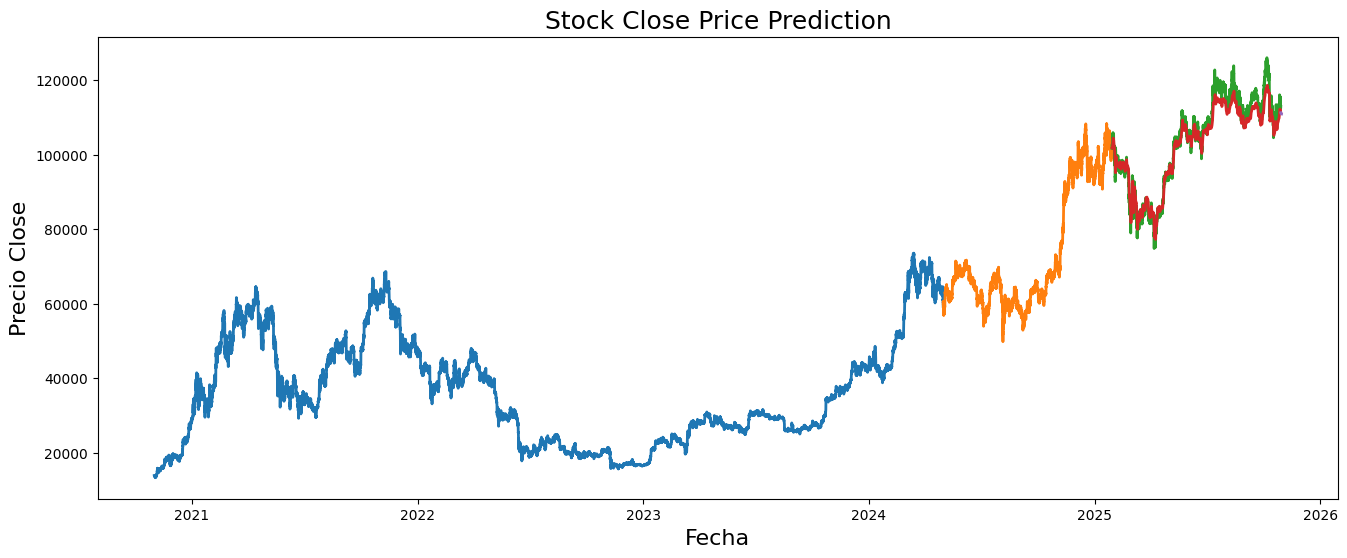

In [419]:
plt.figure(figsize=(16,6))
plt.title('Stock Close Price Prediction', fontsize=18)
plt.xlabel('Fecha', fontsize=16)
plt.ylabel('Precio Close', fontsize=16)
plt.plot(train.index, train['close'], linewidth=2)
plt.plot(val.index, val['close'], linewidth=2)
plt.plot(test.index, test['close'], linewidth=2)
plt.plot(test.index, test['Predictions'], linewidth=2)
plt.plot(df_result.index, df_result['Forecasted'], linewidth=2)

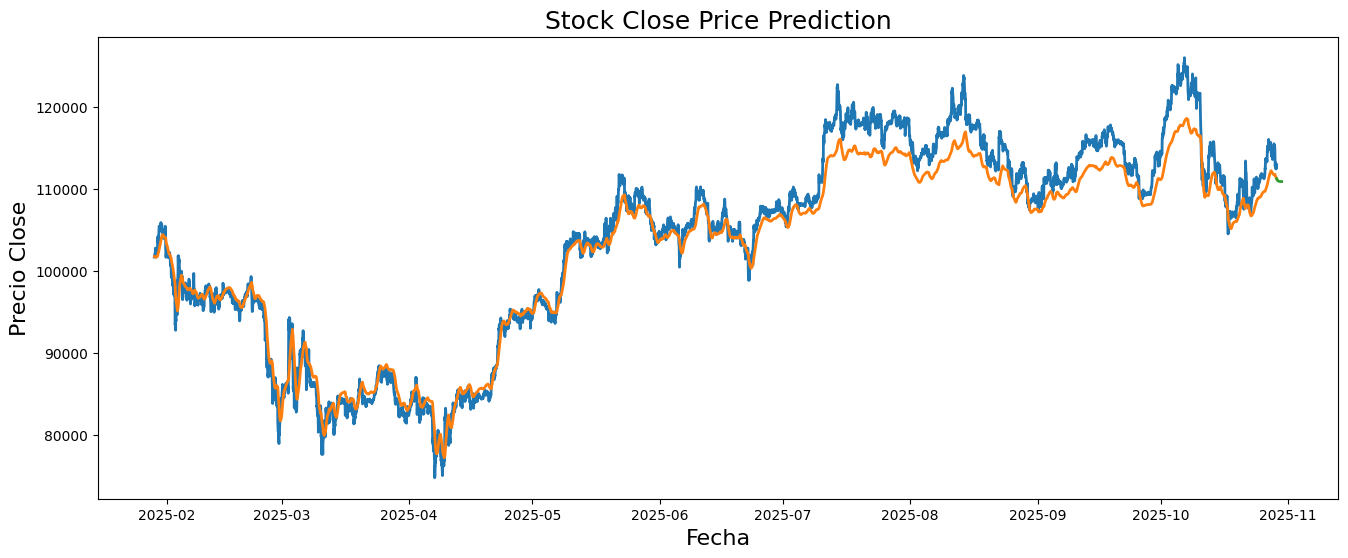

In [420]:
plt.figure(figsize=(16,6))
plt.title('Stock Close Price Prediction', fontsize=18)
plt.xlabel('Fecha', fontsize=16)
plt.ylabel('Precio Close', fontsize=16)
plt.plot(test.index, test['close'], linewidth=2)
plt.plot(test.index, test['Predictions'], linewidth=2)
plt.plot(df_result.index, df_result['Forecasted'], linewidth=2)